# Social Capital & Community Data

## Exploratory Data Analysis

### Importing Libraries & Dataset

In [17]:
# imports
## preprocessing/eda
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
import seaborn as sns

## unsupervised learning
from sklearn.decomposition import PCA # PCA
from sklearn.cluster import KMeans # k-means
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram # hierarchical clustering
from scipy.cluster.hierarchy import fcluster

In [18]:
# social capital economic mobility dataset
df_scem = pd.read_csv("/Users/shaabanlaila/Desktop/summer26-sustainability-of-us-cities/data/social_economic/social_capital_county_economic_mobility.csv")
df_scem = df_scem[['ec_county', 'child_ec_county', 'support_ratio_county', 'volunteering_rate_county', 'civic_organizations_county', 'clustering_county']]
print(df_scem.shape)
df_scem.head()

(3089, 6)


,ec_county,child_ec_county,support_ratio_county,volunteering_rate_county,civic_organizations_county,clustering_county
0,0.72077,1.11754,0.98275,0.04355,0.01518,0.10347
1,0.74313,0.83064,0.98684,0.06117,0.01526,0.09624
2,0.41366,0.58541,0.99911,0.02093,0.01474,0.14911
3,0.63152,0.72265,0.99716,0.05294,0.01439,0.14252
4,0.72562,0.76096,0.99069,0.05704,0.01724,0.11243


3089 rows & 6 columns in dataset

**Economic Connectedness:** How connected lower-income people are to higher-income people socially. Higher values usually mean more cross-class friendships/connections

**Childhood Economic Conectedness:** Economic connectedness measured for children or based on childhood social environments

**Social Support Ratio:** A measure of how much social support exists in that community, maybe based on friendship/support networks

**Volunteering Rate:** The percentage/rate of people who volunteer

**Civic Organizatons Rate:** How common participation in civic/community organizations is

**Social Network Clustering:** How tightly people’s friend groups are connected. High clustering means “my friends are also friends with each other.”

In [19]:
df_scem.info()
df_scem.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3089 entries, 0 to 3088
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ec_county                   3018 non-null   float64
 1   child_ec_county             2729 non-null   float64
 2   support_ratio_county        3089 non-null   float64
 3   volunteering_rate_county    3089 non-null   float64
 4   civic_organizations_county  3089 non-null   float64
 5   clustering_county           3089 non-null   float64
dtypes: float64(6)
memory usage: 144.9 KB


,ec_county,child_ec_county,support_ratio_county,volunteering_rate_county,civic_organizations_county,clustering_county
count,3018.000000,2729.000000,3089.000000,3089.000000,3089.000000,3089.000000
mean,0.814464,0.825335,0.988901,0.078068,0.019762,0.116456
std,0.177126,0.221210,0.015467,0.034841,0.009850,0.020364
min,0.294690,0.221880,0.696760,0.009650,0.003490,0.071620
25%,0.695607,0.678750,0.986830,0.055280,0.014020,0.102690
50%,0.806830,0.815510,0.993740,0.073280,0.017780,0.114570
75%,0.936783,0.962130,0.996720,0.093960,0.023060,0.127240
max,1.359700,1.611360,1.000000,0.308736,0.195429,0.260970


- All variables are numeric

- Some missing data -- 71 in economic connectedness, 360 in childhood economic connectedness

- Possible right-skew/high outliers in:
    1. volunteering rate (mean 0.078, med 0.073, max 0.309): max is much higher than where most counties fall

    1. civic organization rate (mean 0.020, med 0.018, max 0.195): max is way above 75% percentile
    
    1. social support ratio (mean 0.989, med 0.994, min 0.697, max 1.000): most numbers seem to be around 1, but the minimum is much lower

### Visualizations

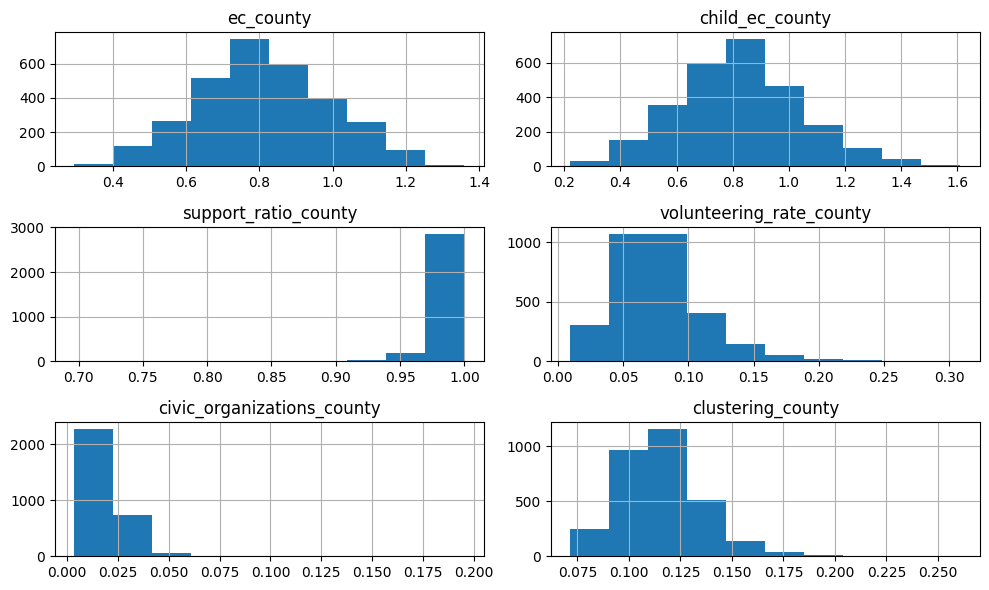

In [20]:
# histograms
df_scem.hist(figsize=(10,6))
plt.tight_layout()
plt.show()

- Economic connectedness and childhood economic connectedness seem to be fairly normally distributed

- Social support ratio has an extreme left-skew, which was mentioned briefly earlier

- Volunteering rate, civic organization rate, and social network clustering have strong right-skews, especially civic organization rate with majority of its values between 0 and 0.025.

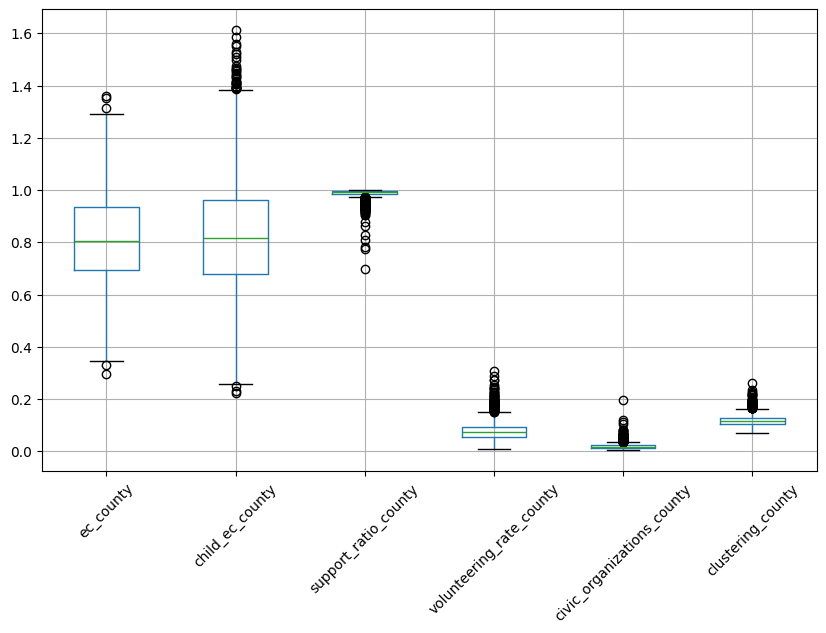

In [21]:
# boxplots
df_scem.boxplot(figsize=(10,6))
plt.xticks(rotation=45)
plt.show()

Same observations as above with the histograms. Outliers seem to be extremely common in this dataset.

In [22]:
# checking correlation between variables
df_scem.corr()

,ec_county,child_ec_county,support_ratio_county,volunteering_rate_county,civic_organizations_county,clustering_county
ec_county,1.000000,0.615241,-0.268590,0.390049,0.370408,-0.270103
child_ec_county,0.615241,1.000000,-0.465381,0.132104,0.085321,-0.482048
support_ratio_county,-0.268590,-0.465381,1.000000,0.024665,-0.009087,0.524740
volunteering_rate_county,0.390049,0.132104,0.024665,1.000000,0.282239,-0.037363
civic_organizations_county,0.370408,0.085321,-0.009087,0.282239,1.000000,0.039453
clustering_county,-0.270103,-0.482048,0.524740,-0.037363,0.039453,1.000000


There does not seem to be an issue with multicollinearity in this dataset. The highest correlations between predictors (if economic connectedness is outcome) are between clustering rate and social support rate, which makes sense since a tighter-knit community would likely exhibit more social support.

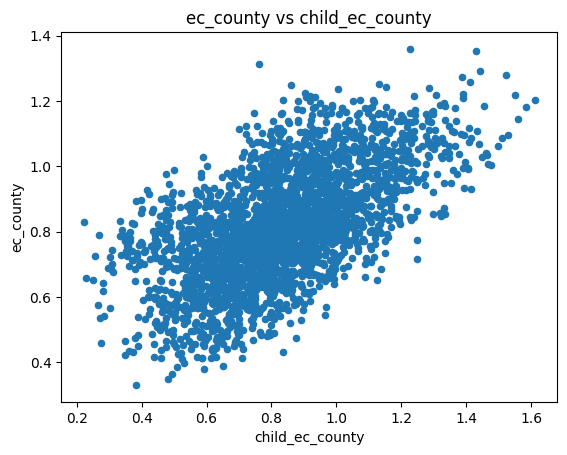

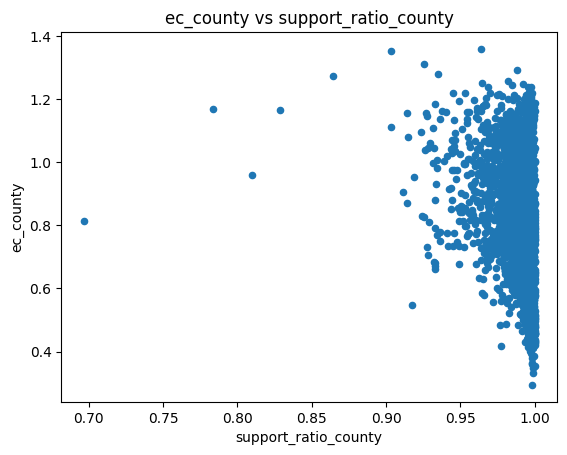

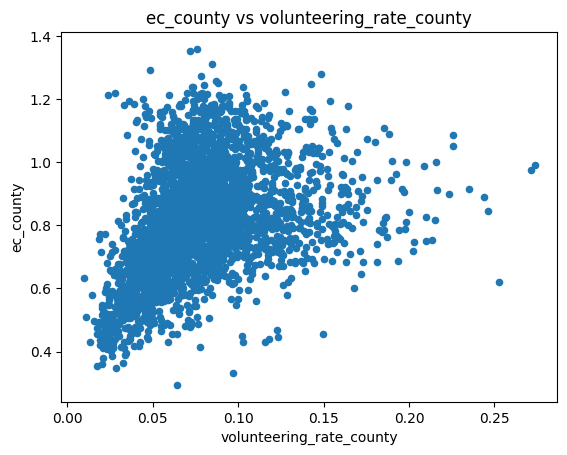

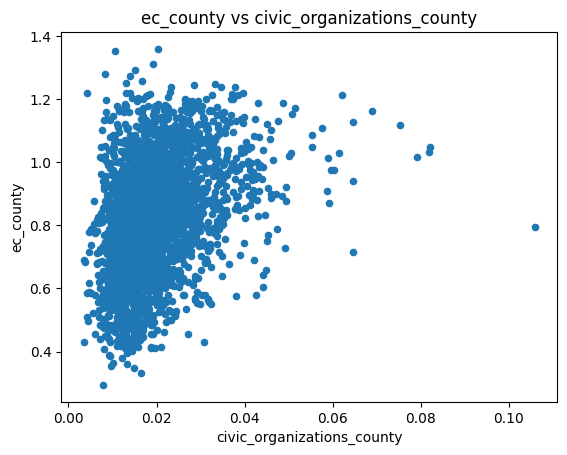

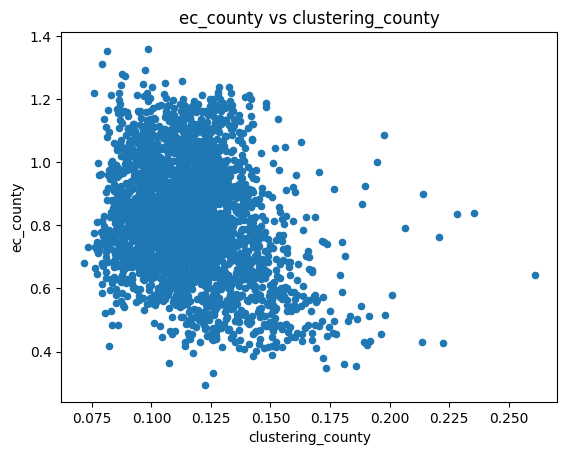

In [23]:
# scatterplots with economic connectedness as outcome variable
predictors = [
    "child_ec_county",
    "support_ratio_county",
    "volunteering_rate_county",
    "civic_organizations_county",
    "clustering_county"
]

for col in predictors:
    df_scem.plot.scatter(x=col, y="ec_county")
    plt.title(f"ec_county vs {col}")
    plt.show()

- Moderate positive relationship between childhood ec and general ec

- No observed relationship between ec and social support ratio

- Weak positive relationship between volunteering rate and ec

- Weak positive relationship between ec and civic organization rate

- No observed relationship between ec and social network clustering

## Conclusions

Overall, the county-level social capital measures that seem to be most strongly related to economic connectedness are childhood economic connectedness (trivial), volunteering rate, and civic organization rate (in that order).

- Childhood economic connectedness has the strongest relationship with economic connectedness, but this is expected because the measures are closely related.

- Volunteering rate shows a strong positive relationship, suggesting more community engagement may be linked to higher economic connectedness.

- Civic organization rate also appears positively related, meaning counties with more civic participation tend to have higher connectedness.

- Other social capital variables seem weaker and may be less important predictors.

## Unsupervised Learning

### PCA

In [24]:
# PCA
## selecting numeric data
df_scem_m = df_scem.dropna() # dropping NA for modeling purposes
X = df_scem_m.select_dtypes(include="number")

## standardize data -- all variables on same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## fitting PCA
pca = PCA(n_components = 2) # 2D
X_pca = pca.fit_transform(X_scaled)
pca.components_

array([[ 0.49839508,  0.53627258, -0.45180026,  0.20644311,  0.13400082,
        -0.44644777],
       [ 0.31006539, -0.04373368,  0.3612054 ,  0.53427328,  0.59989315,
         0.35518693]])

**Loadings of PC1:** [ 0.49839508,  0.53627258, -0.45180026,  0.20644311,  0.13400082,  -0.44644777 ]
- High variable 1 & 2, low variable 3 & 6
- PC1 mainly separates counties with higher economic connectedness and childhood economic connectedness from counties with higher social support ratio and social network clustering

**Loadings of PC2:** [ 0.31006539, -0.04373368,  0.3612054 ,  0.53427328,  0.59989315,  0.35518693 ]
- High variable 4 & 5
- PC2 mainly reflects higher volunteering rate and civic organizations

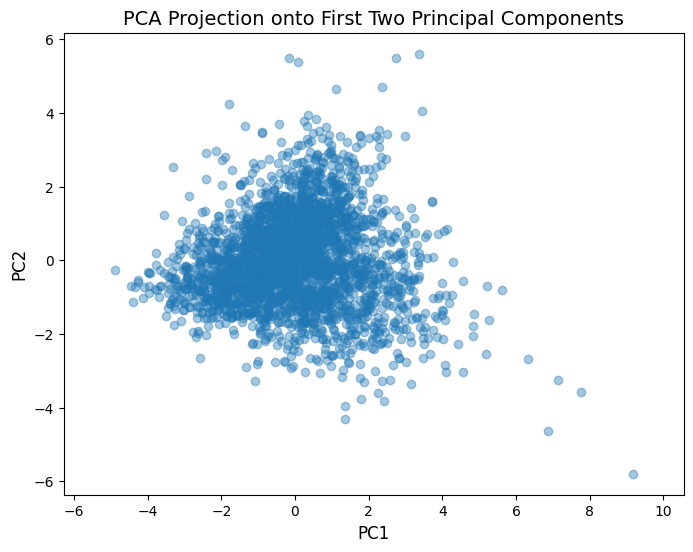

In [25]:
# plot PCs
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.4)

plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)
plt.title("PCA Projection onto First Two Principal Components", fontsize=14)
plt.axis("equal")
plt.show()

Graph answers the question "Where does each row land if I summarize the 6 original variables using the two biggest PCA patterns?"

Based on our observations of the loadings above, points to the right correspond to high x1 & x2, low x3 & x6 and points high up correspond to high x4 & x5

- **Most observations are clustered near the center:** Most observations ar enot extremely different from each other according to PC1 & PC2

- **There are some outliers:** Especially points far to the right on PC1 and far down on PC2. Those observations are unusual compared to the rest.

- **There is not an obvious clean clustering pattern:** The cloud is mostly one blob, not clearly separated groups. So PCA is not showing strong natural clusters in the first two components.

In [26]:
# explained ratios
print("PC1:", pca.explained_variance_ratio_[0])
print("PC2:", pca.explained_variance_ratio_[1])
print("Total:", pca.explained_variance_ratio_[:2].sum())

PC1: 0.4062234117194253
PC2: 0.2687522932837666
Total: 0.6749757050031919


- From the 6 original variables, PCA made new summary variables (PCs), which helps figure out the main ways these observations differ from each other.

- PC1 & PC2 are new summary variables made from weighted combinations of the original variables. PC1 captures the strongest pattern of variation in the data, followed by PC2

- Since the sum of PC1+PC2 is about 67%, this plot summarizes the data well. In words, this means that the first two principal components explain 67% of the total variation in the dataset across the six variables (majority)

In [27]:
# making PCA dataframe based off new variables
pc_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=X.index)
df_with_pcs = df_scem_m.copy()
df_with_pcs["PC1"] = pc_df["PC1"]
df_with_pcs["PC2"] = pc_df["PC2"]

df_with_pcs.sort_values("PC1", ascending=False).head() ## observations/counties with highest PC scores

,ec_county,child_ec_county,support_ratio_county,volunteering_rate_county,civic_organizations_county,clustering_county,PC1,PC2
250,1.16885,1.29898,0.78333,0.07480,0.01142,0.08568,9.176847,-5.792056
2882,1.16657,1.17096,0.82876,0.07343,0.02564,0.08160,7.775726,-3.566747
2793,1.27232,1.38834,0.86424,0.07839,0.01405,0.08906,7.138295,-3.248814
409,0.95985,0.83256,0.80991,0.07512,0.02164,0.08178,6.881573,-4.642917
261,1.35327,1.43038,0.90309,0.07197,0.01052,0.08127,6.330161,-2.672957


In [28]:
# checking outliers
display(df_with_pcs.sort_values("PC1", ascending=False).head(10))
display(df_with_pcs.sort_values("PC2").head(10))

,ec_county,child_ec_county,support_ratio_county,volunteering_rate_county,civic_organizations_county,clustering_county,PC1,PC2
250,1.16885,1.29898,0.78333,0.07480,0.01142,0.08568,9.176847,-5.792056
2882,1.16657,1.17096,0.82876,0.07343,0.02564,0.08160,7.775726,-3.566747
2793,1.27232,1.38834,0.86424,0.07839,0.01405,0.08906,7.138295,-3.248814
409,0.95985,0.83256,0.80991,0.07512,0.02164,0.08178,6.881573,-4.642917
261,1.35327,1.43038,0.90309,0.07197,0.01052,0.08127,6.330161,-2.672957
578,1.28088,1.52210,0.93516,0.14855,0.00820,0.08781,5.626938,-0.812001
1200,1.14585,1.56065,0.92722,0.08151,0.01700,0.09003,5.256566,-1.615860
263,1.15659,1.19841,0.91428,0.10185,0.02751,0.08715,5.206351,-0.710096
2872,1.09514,1.52992,0.92376,0.07298,0.01143,0.08204,5.175428,-2.533747
2839,1.21831,1.55087,0.94528,0.07891,0.01310,0.08654,4.869245,-1.454785


,ec_county,child_ec_county,support_ratio_county,volunteering_rate_county,civic_organizations_county,clustering_county,PC1,PC2
250,1.16885,1.29898,0.78333,0.07480,0.01142,0.08568,9.176847,-5.792056
409,0.95985,0.83256,0.80991,0.07512,0.02164,0.08178,6.881573,-4.642917
1808,0.68067,0.64668,0.93306,0.02304,0.00649,0.07162,1.371566,-4.300245
414,0.54623,0.69616,0.91740,0.02438,0.01470,0.08809,1.364574,-3.947332
365,0.73128,0.88922,0.92736,0.03782,0.01037,0.07338,2.410173,-3.805777
1846,0.77996,0.77779,0.93655,0.04205,0.00469,0.07887,1.786631,-3.754753
243,0.81186,0.78512,0.92894,0.04752,0.00754,0.07716,2.263894,-3.598962
2882,1.16657,1.17096,0.82876,0.07343,0.02564,0.08160,7.775726,-3.566747
245,0.83072,1.06210,0.92438,0.05429,0.01001,0.08020,3.150731,-3.363849
220,0.73533,0.91341,0.94183,0.03877,0.01036,0.08042,1.865338,-3.292341


**Outlier Observations:**

The top PC1 outliers (highest economic connectedness and childhood EC) identify counties where cross-class social bridges are strongest — suggesting higher economic mobility potential. The bottom PC1 outliers (lowest EC, highest social support/clustering) reveal tight-knit communities with strong internal bonds but less economic diversity. These contrasts illustrate the tradeoff between social cohesion (clustering) and economic opportunity bridging (connectedness).

### K-Means

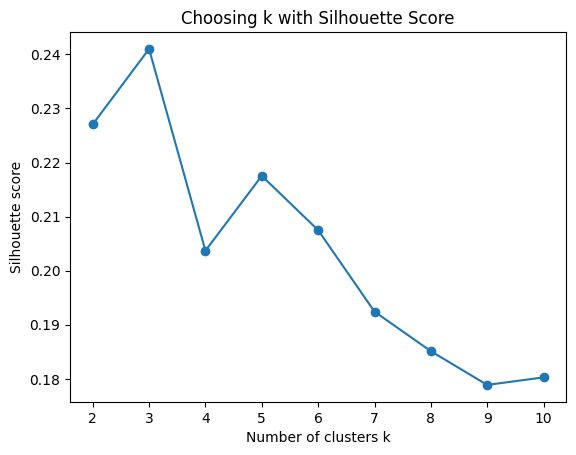

In [29]:
# k-means
scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

plt.plot(range(2, 11), scores, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Choosing k with Silhouette Score")
plt.show()

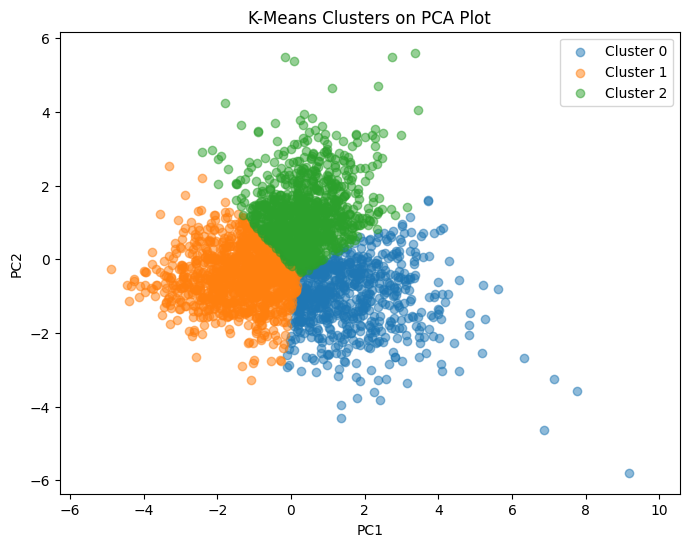

In [30]:
# fitting chosen k
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_with_pcs["cluster"] = clusters

# plotting clusters on PCA graph
plt.figure(figsize=(8, 6))

for cluster in sorted(df_with_pcs["cluster"].unique()):
    subset = df_with_pcs[df_with_pcs["cluster"] == cluster]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Cluster {cluster}", alpha=0.5)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters on PCA Plot")
plt.legend()
plt.axis("equal")
plt.show()

- K-means made 3 groups, as seen above. One cluster groups high-connectedness counties (right on PC1), another groups high-participation counties (up on PC2), and the third contains mixed/moderate social capital counties.

- Clusters are not super separated. The groups overlap significantly near the center, showing K-means forced the gradient into 3 regions.

- Silhouette score of k = 3 seems to be around 0.2-0.3, which confirms our weak clusters.

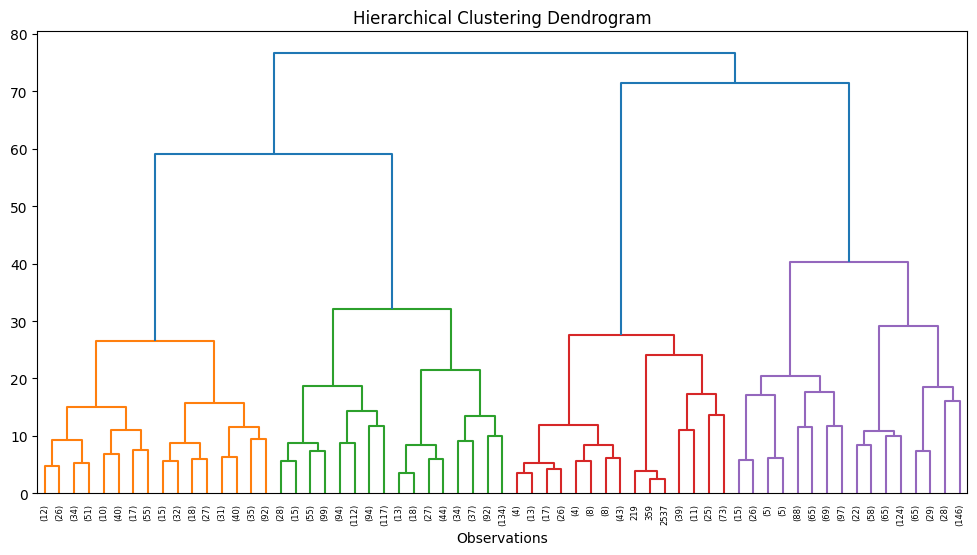

In [31]:
# hierarchical clustering dendrogram
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode="level", p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Observations")
plt.show()

hier_clusters = fcluster(Z, t=3, criterion="maxclust")
df_with_pcs["hier_cluster"] = hier_clusters

- Looking at our dendrogram above, we can see how observations are grouped based on similarity across the scaled variables.

- Cutting the tree around height 3 produces approximately 3 clusters, with some branches merging earlier than others, indicating variation in social capital profiles.

- Some early-separating clusters (appearing at lower heights) represent counties with distinctive social capital patterns — either exceptionally high connectedness/participation or very low values.

- Most counties merge gradually, suggesting a gradient rather than clean categories — many counties fall between the distinct social capital archetypes.

- Overall, the dendrogram suggests moderate clustering structure rather than perfectly separated groups.

## Key Findings: Social Capital as a Sustainability Factor

**What the social capital data reveals about long-term relocation sustainability:**

1. **Economic Connectedness** (cross-class friendships, social bridges) — Strong correlate with economic mobility. Counties where people from different income levels know each other show better opportunity structures, independent of county wealth.

2. **Civic Participation** (volunteering, organizations) — Reflects community engagement and collective efficacy. High-participation counties likely have stronger informal safety nets and problem-solving capacity.

3. **Social Network Structure** (clustering, cohesion) — Tight-knit communities offer mutual support but may limit exposure to diverse opportunities. Moderate clustering (rather than extreme) may be optimal.

4. **The Economic Connectedness-Clustering Tradeoff** — Counties can't maximize both: high-clustering communities tend toward insularity (fewer cross-class ties), while open networks with high economic connectedness have weaker internal cohesion.

**County Profiles by Social Capital:**

- **High-Connectedness Clusters**: More diverse social networks, stronger upward mobility potential, but possibly weaker local cohesion. Best for ambitious individuals seeking opportunity networks.

- **High-Participation Clusters**: Strong civic engagement, tight communities, good local support systems. Best for families valuing community involvement and social safety nets.

- **Mixed/Moderate Clusters**: Moderate on both dimensions—neither exceptionally strong connectedness nor participation. Represent the median U.S. county profile.

**Critical insight for 20-year relocation**: Social capital matters as much as economics for long-term thriving. A county can be wealthy but isolated (low connectedness), or engaged but poor (high participation, low income). Seek counties where both your economic opportunity network AND civic/community structures are strong.

## Synthesis: Mobility + Social Capital

Together, the mobility and social capital analyses reveal that **sustainable 20-year relocation requires balancing four independent dimensions—economic opportunity, environmental quality, social connectedness, and commute/infrastructure—none of which is substitutable for the others**. A county strong on economics but weak on social capital (or vice versa) will provide an incomplete foundation for long-term thriving. The best relocation choice depends on which tradeoffs align with your personal priorities, but any choice should be evaluated across all four dimensions simultaneously.